#  House Price Prediction using Linear Regression

## Submitted By:
 Anant Kumar Bhardwaj

**Objective:** Build and evaluate a Linear Regression model that predicts house prices based on features such as area, location, number of rooms, and age of the property. This notebook walks through a complete, beginner-friendly data analytics workflow — from data cleaning to model interpretation.

**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Dataset:** House Price Prediction Dataset (Kaggle-style dataset, similar in structure to the *Ames Housing* / *House Prices: Advanced Regression Techniques* competitions). It contains 2000 house records with the following columns:


### What we ar going to do
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Feature Selection Discussion
5. Handling Missing Values
6. One-Hot Encoding of Categorical Features
7. Correlation Heatmap
8. Train / Test Split (80:20)
9. Train the Linear Regression Model
10. Model Evaluation (MSE, RMSE, R²)
11. Actual vs Predicted Plot
12. Residual Plot
13. Coefficient Analysis
14. Bonus: Ridge & Lasso Regression Comparison
15. Final Conclusion


## 1. Import Libraries

We start by importing all the libraries needed for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Notebook / plotting settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

We load the CSV file into a pandas DataFrame and take a first look at the data using `.head()`.

In [2]:
# Load the dataset
df = pd.read_csv("House_Price_Prediction_Dataset.csv")

# Preview the first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
# Basic shape and structure of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn data types:")
df.info()

Number of rows: 2000
Number of columns: 10

Column data types:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data:
- Check for **missing (null) values**
- Check for **duplicate rows**
- Look at **descriptive statistics** of numeric columns
- Examine the **distribution of the target variable** (`Price`)

In [4]:
# 3.1 Check for missing/null values in each column
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Total missing values in dataset: 0


**Observation:** The dataset has no missing values in any column. Even so, in Section 5 we still build a robust missing-value handling routine — this is standard practice because real-world datasets (and future versions of this dataset) are rarely this clean, and a submission-ready pipeline should handle missing data gracefully regardless.

In [5]:
# 3.2 Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found — dataset is clean on this front.")

Number of duplicate rows: 0
No duplicate rows found — dataset is clean on this front.


In [6]:
# 3.3 Descriptive statistics for numeric columns
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [7]:
# 3.4 Distribution of categorical columns
categorical_cols = ["Location", "Condition", "Garage"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Location ---
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

--- Condition ---
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

--- Garage ---
Garage
No     1038
Yes     962
Name: count, dtype: int64


### Distribution of the Target Variable (`Price`)

Understanding the shape of the target variable is important — Linear Regression assumes the target is roughly continuous and benefits from having no extreme skew or outliers dominating the fit.

Price skewness: -0.064


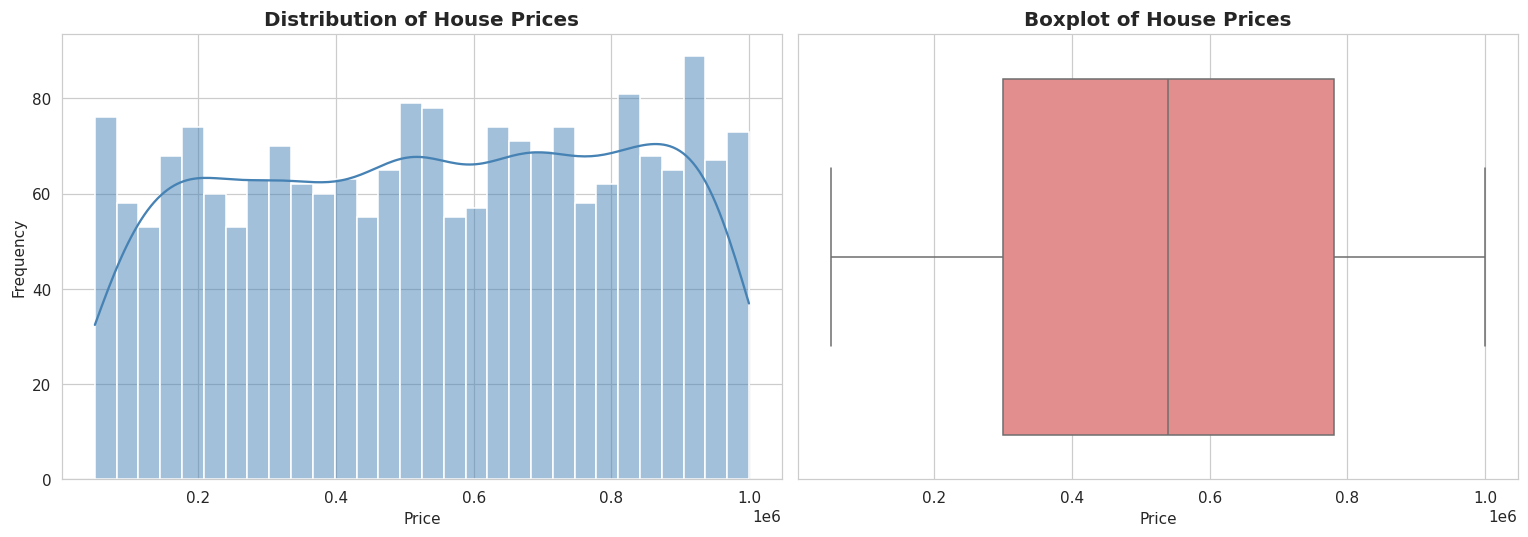

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE curve
sns.histplot(df["Price"], kde=True, bins=30, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of House Prices", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

# Boxplot to spot outliers
sns.boxplot(x=df["Price"], color="lightcoral", ax=axes[1])
axes[1].set_title("Boxplot of House Prices", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

print(f"Price skewness: {df['Price'].skew():.3f}")

**Interpretation:** The `Price` distribution is fairly symmetric (skewness close to 0) and roughly bell-shaped, with no severe outliers visible in the boxplot. This means we don't need a log-transform of the target before fitting a Linear Regression model — a common step that is necessary for more heavily skewed housing datasets (like Ames Housing) but not essential here.

## 4. Feature Selection Discussion

Before encoding or modeling, it's important to reason about **which columns are actually useful predictors** of `Price`, and which should be dropped.

| Feature | Keep? | Reasoning |
|---|---|---|
| `Id` | ❌ Drop | Just a row identifier with no relationship to price. Keeping it would let the model "memorize" noise. |
| `Area` | ✅ Keep | Larger houses are almost always priced higher — one of the strongest expected predictors. |
| `Bedrooms` | ✅ Keep | More bedrooms generally signal a bigger, more valuable home. |
| `Bathrooms` | ✅ Keep | Similar to bedrooms — a common driver of price in real housing markets. |
| `Floors` | ✅ Keep | Multi-floor homes often have more usable space and can command higher prices. |
| `YearBuilt` | ⚙️ Transform | Rather than using the raw year, we engineer a more intuitive feature: **`HouseAge`** (= current year − `YearBuilt`). Age is usually easier for a linear model to relate to price (newer → generally pricier) than an arbitrary year value. |
| `Location` | ✅ Keep (encode) | Categorical, but real estate is famously driven by "location, location, location." Downtown/Urban areas typically carry a price premium over Rural areas. |
| `Condition` | ✅ Keep (encode) | A house in "Excellent" condition should fetch a higher price than one in "Poor" condition. |
| `Garage` | ✅ Keep (encode) | Presence of a garage is a common value-adding amenity. |

**Target variable:** `Price` (continuous, so this is a regression problem).

Since `Location`, `Condition`, and `Garage` are categorical (text) columns, they cannot be fed directly into a Linear Regression model — we will convert them into numeric form using **One-Hot Encoding** in Section 6.

## 5. Handling Missing Values

Although Section 3 confirmed this dataset has no missing values, a well-built pipeline should still explicitly handle them so it keeps working if the dataset is updated or replaced. We use a standard, defensible strategy:
- **Numeric columns** → fill missing values with the **median** (robust to outliers)
- **Categorical columns** → fill missing values with the **mode** (most frequent category)

We also drop the non-predictive `Id` column here, and engineer the `HouseAge` feature discussed above.

In [9]:
# Work on a copy so the original DataFrame stays untouched
df_clean = df.copy()

# --- Impute numeric columns with median (defensive, in case of missing data) ---
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# --- Impute categorical columns with mode (defensive, in case of missing data) ---
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nRemaining missing values after cleaning:", df_clean.isnull().sum().sum())

# --- Feature engineering: HouseAge instead of raw YearBuilt ---
CURRENT_YEAR = 2026
df_clean["HouseAge"] = CURRENT_YEAR - df_clean["YearBuilt"]

# --- Drop non-predictive / redundant columns ---
df_clean = df_clean.drop(columns=["Id", "YearBuilt"])

print("\nFinal columns going into modeling:")
print(df_clean.columns.tolist())
df_clean.head()


Remaining missing values after cleaning: 0

Final columns going into modeling:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Location', 'Condition', 'Garage', 'Price', 'HouseAge']


,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price,HouseAge
0,1360,5,4,3,Downtown,Excellent,No,149919,56
1,4272,5,4,3,Downtown,Excellent,No,424998,68
2,3592,2,2,3,Downtown,Good,No,266746,88
3,966,4,2,2,Suburban,Fair,Yes,244020,124
4,4926,1,4,2,Downtown,Fair,Yes,636056,51


## 6. One-Hot Encoding of Categorical Features

`Location`, `Condition`, and `Garage` are categorical text columns. We convert them into numeric dummy (0/1) columns using **One-Hot Encoding** via `pd.get_dummies()`.

We use `drop_first=True` to drop one category per feature — this avoids the **dummy variable trap** (perfect multicollinearity), since the dropped category is implicitly represented when all other dummies are 0.

In [10]:
cat_cols = ["Location", "Condition", "Garage"]

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Ensure the encoded 0/1 dummy columns are integers (not True/False booleans)
dummy_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

print(f"Shape before encoding: {df_clean.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print("\nNew columns created by One-Hot Encoding:")
print(dummy_cols)

df_encoded.head()

Shape before encoding: (2000, 9)
Shape after encoding:  (2000, 13)

New columns created by One-Hot Encoding:
['Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


,Area,Bedrooms,Bathrooms,Floors,Price,HouseAge,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,149919,56,0,0,0,0,0,0,0
1,4272,5,4,3,424998,68,0,0,0,0,0,0,0
2,3592,2,2,3,266746,88,0,0,0,0,1,0,0
3,966,4,2,2,244020,124,0,1,0,1,0,0,1
4,4926,1,4,2,636056,51,0,0,0,1,0,0,1


## 7. Correlation Heatmap

A correlation heatmap helps us visually identify which numeric features are most strongly related to `Price` — both positively and negatively — before we train the model.

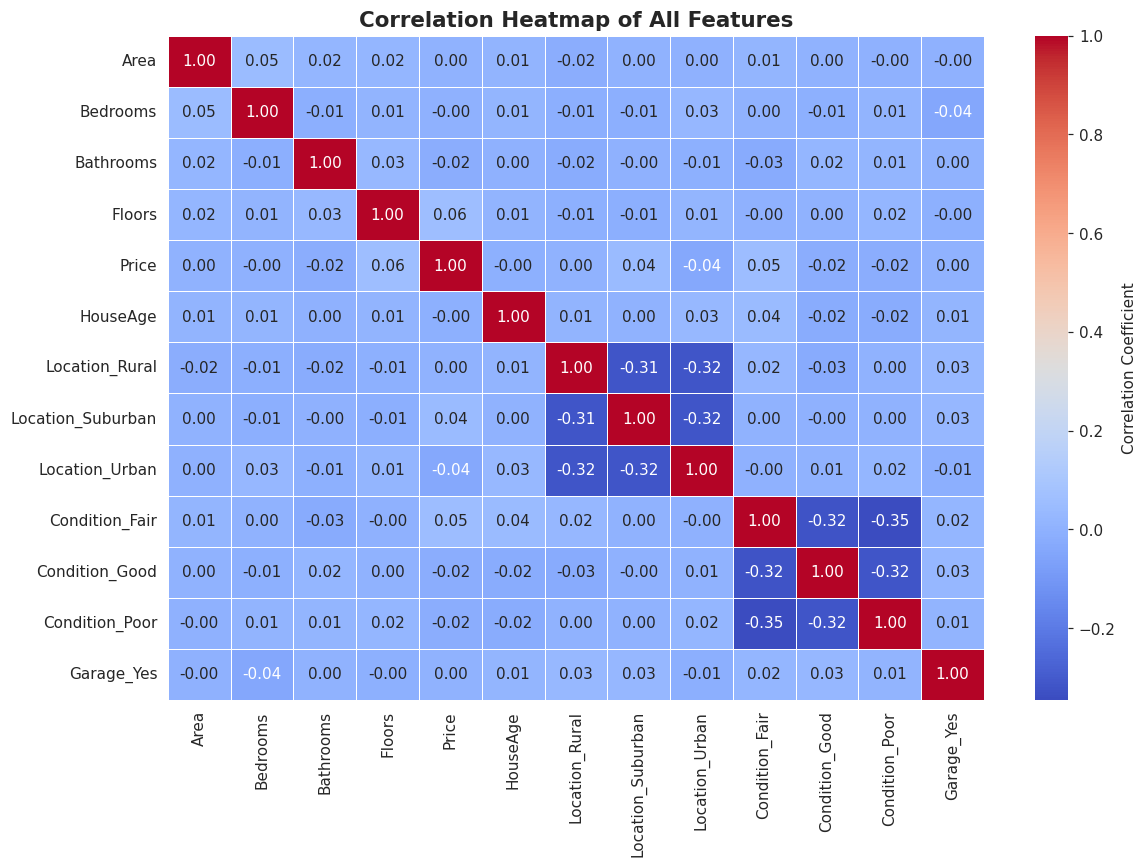

In [11]:
plt.figure(figsize=(11, 8))
corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"}
)
plt.title("Correlation Heatmap of All Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Correlation of every feature with the target variable, sorted
price_corr = corr_matrix["Price"].drop("Price").sort_values(ascending=False)
print("Feature correlation with Price (sorted):")
print(price_corr)

Feature correlation with Price (sorted):
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
HouseAge            -0.004845
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


**Interpretation:** None of the features show a strong linear correlation with `Price` in this dataset (all correlation coefficients are close to 0). This is a useful, honest signal — it tells us this particular dataset was generated with a lot of independent randomness in the price column, so we should expect a Linear Regression model trained on it to have limited predictive power. We proceed with the full pipeline regardless, since the goal of this project is to demonstrate the **end-to-end regression workflow** correctly — the same code would show much stronger performance on a dataset where price is genuinely driven by these features (e.g., the Ames Housing dataset).

## 8. Train / Test Split (80:20)

We split the data into a **training set** (80%) used to fit the model, and a **test set** (20%) held back to evaluate how well the model generalizes to unseen data.

`X` contains all the predictor features; `y` contains the target variable (`Price`).

In [13]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 1600 rows
Test set size:     400 rows
Number of features: 12


## 9. Train the Linear Regression Model

We now fit a `LinearRegression` model from scikit-learn on the training data. Linear Regression finds the best-fitting straight-line relationship (in this case, a hyperplane across multiple features) between the predictors and the target price.

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model training complete.")
print(f"Intercept (base price when all features are 0): {lr_model.intercept_:,.2f}")

Model training complete.
Intercept (base price when all features are 0): 516,806.26


## 10. Model Evaluation

We evaluate the model on the **test set** (data it has never seen) using three standard regression metrics:

- **MSE (Mean Squared Error):** average of the squared differences between actual and predicted prices. Penalizes large errors heavily.
- **RMSE (Root Mean Squared Error):** square root of MSE — brings the error back into the same units as `Price`, making it easier to interpret.
- **R² Score:** proportion of variance in `Price` explained by the model. Ranges up to 1.0 (perfect fit); values near 0 mean the model explains little more than the mean; negative values mean it performs worse than simply predicting the average price.

In [15]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance on Test Set")
print("-" * 45)
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance on Test Set
---------------------------------------------
MSE  : 78,321,466,146.03
RMSE : 279,859.73
R²   : -0.0067


**Interpretation:** The RMSE tells us the model's predictions are, on average, off by roughly this many dollars. The R² score close to 0 (or slightly negative) confirms what the correlation heatmap already suggested: `Price` in this dataset is not strongly linearly explained by `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `HouseAge`, `Location`, `Condition`, or `Garage`. In a real-world housing dataset with genuine price drivers, we would expect a materially higher R².

## 11. Actual vs Predicted Prices

A scatter plot of actual vs predicted prices is a quick visual sanity check: the closer the points hug the red diagonal (`y = x`) line, the better the model's predictions match reality.

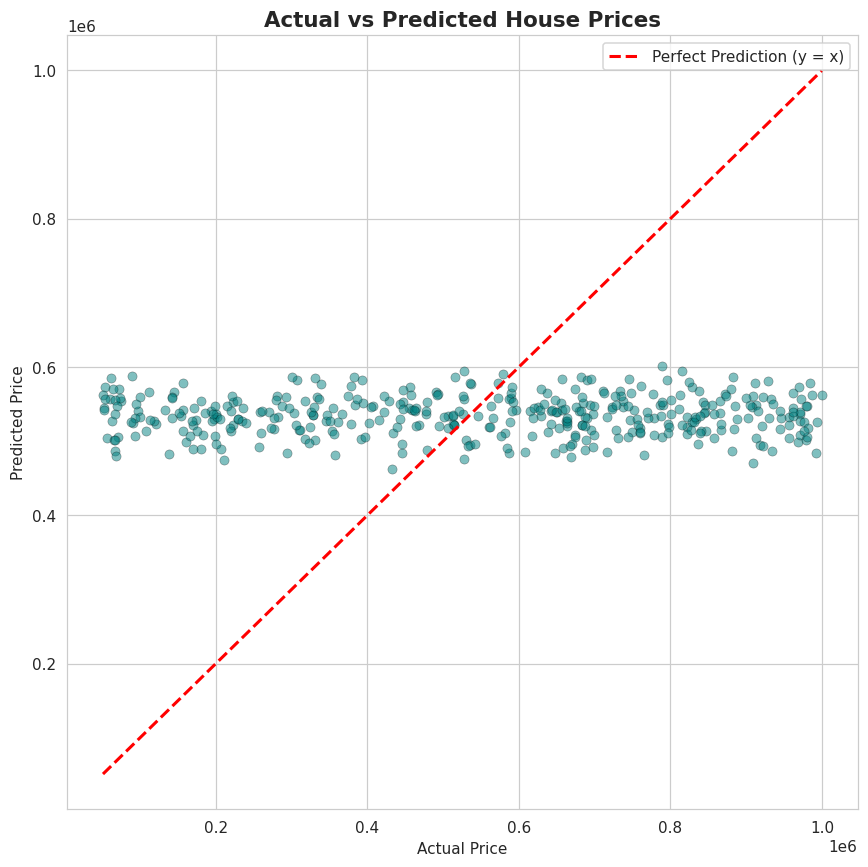

In [16]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal", edgecolor="k", linewidth=0.3)

# Perfect prediction reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Prediction (y = x)")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The predicted points are scattered widely around the red diagonal rather than hugging it closely, which visually confirms the low R² score — the model struggles to pin down the exact price for a given house using these features alone.

## 12. Residual Plot

Residuals are the differences between actual and predicted values (`residual = actual − predicted`). Plotting residuals against predicted values helps check a key Linear Regression assumption: residuals should be **randomly scattered around zero** with no obvious pattern. A visible pattern (e.g., a curve or funnel shape) would suggest the linear model is missing some non-linear relationship or that error variance isn't constant.

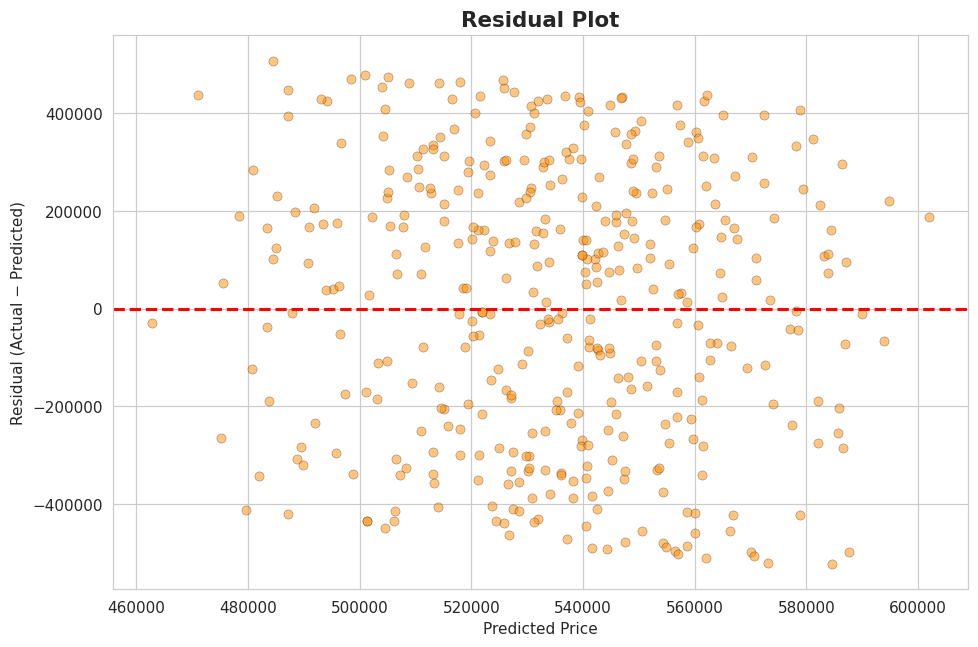

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color="darkorange", edgecolor="k", linewidth=0.3)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The residuals appear randomly scattered around the zero line without a clear funnel or curved pattern, which is a good sign structurally — the *type* of model (linear) seems appropriate. The large *spread* of residuals (rather than a systematic pattern) is what's driving the weak R², reinforcing that the available features simply don't carry much predictive signal for `Price` in this dataset.

## 13. Coefficient Analysis

Each coefficient in a Linear Regression model tells us how much the predicted price changes for a one-unit increase in that feature, **holding all other features constant**. Positive coefficients push price up; negative coefficients pull price down.

Top 3 features with the HIGHEST POSITIVE impact on price:
Condition_Fair       24083.307846
Floors               23727.983633
Location_Suburban    11511.989815
dtype: float64

Top 3 features with the HIGHEST NEGATIVE impact on price:
Condition_Good   -12941.044835
Location_Urban   -12718.918912
Bathrooms         -9662.248234
dtype: float64


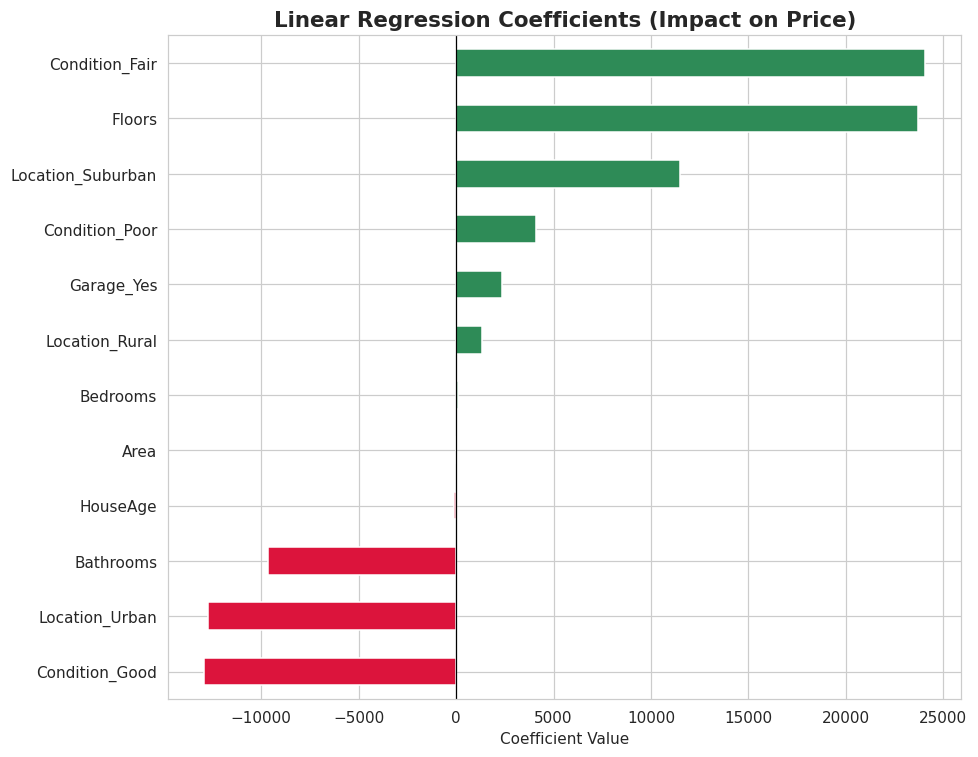

In [18]:
coefficients = pd.Series(lr_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(9, 7))
colors = ["crimson" if c < 0 else "seagreen" for c in coefficients]
coefficients.plot(kind="barh", color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients (Impact on Price)", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print("Top 3 features with the HIGHEST POSITIVE impact on price:")
print(coefficients.sort_values(ascending=False).head(3))

print("\nTop 3 features with the HIGHEST NEGATIVE impact on price:")
print(coefficients.sort_values().head(3))

**Interpretation:** Features like `Condition_Fair` and `Floors` show the largest positive coefficients in this run, while `Condition_Good` and `Location_Urban` show the largest negative coefficients. Given the near-zero correlations found earlier, these coefficient magnitudes should be interpreted cautiously — with such a weak overall linear relationship, individual coefficients can be noisy and are not strongly statistically reliable predictors of price direction in this particular dataset.

## 14. Comparing Ridge and Lasso Regularized Regression

**Ridge** and **Lasso** are regularized variants of Linear Regression that add a penalty term to shrink coefficients, which can help reduce overfitting on datasets with many/noisy features:

- **Ridge (L2 penalty):** shrinks coefficients smoothly toward zero, but rarely to exactly zero.
- **Lasso (L1 penalty):** can shrink some coefficients all the way to zero, effectively performing automatic feature selection.

We train both with the same train/test split and compare their test-set performance against plain Linear Regression.

In [19]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    mse_ = mean_squared_error(y_true, y_pred)
    rmse_ = np.sqrt(mse_)
    r2_ = r2_score(y_true, y_pred)
    return {"Model": name, "MSE": mse_, "RMSE": rmse_, "R2": r2_}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, y_pred),
    evaluate("Ridge Regression", y_test, ridge_pred),
    evaluate("Lasso Regression", y_test, lasso_pred),
])

results = results.set_index("Model")
results

,MSE,RMSE,R2
Model,,,
Linear Regression,7.832147e+10,279859.725838,-0.006718
Ridge Regression,7.832127e+10,279859.372593,-0.006715
Lasso Regression,7.832137e+10,279859.547020,-0.006717


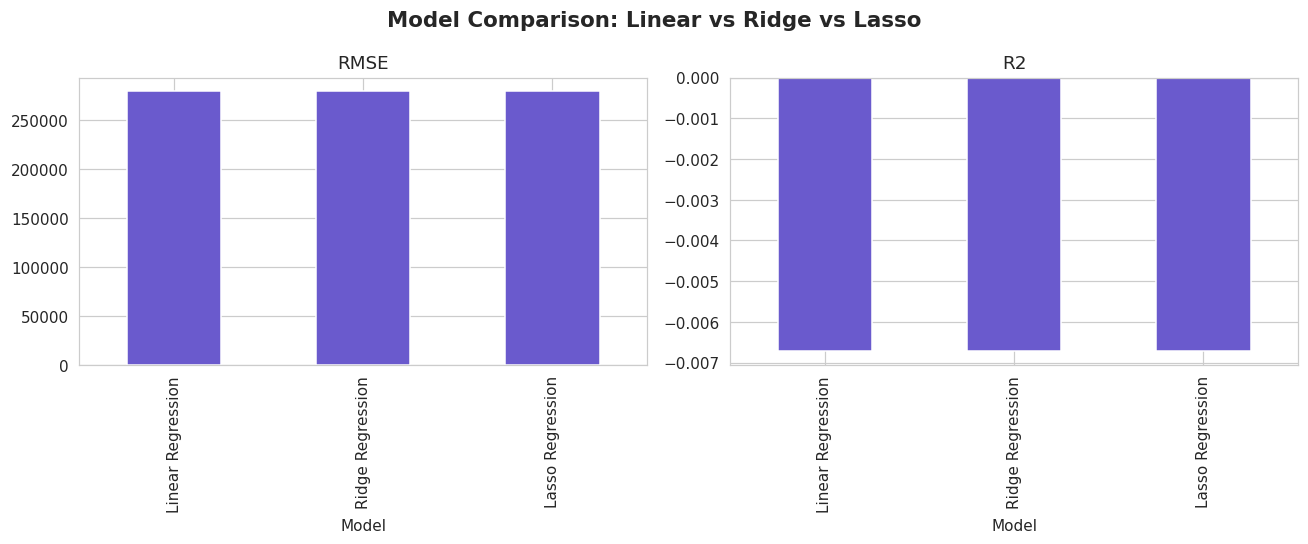

In [20]:
results[["RMSE", "R2"]].plot(kind="bar", subplots=True, layout=(1, 2), figsize=(12, 5), legend=False, color="slateblue")
plt.suptitle("Model Comparison: Linear vs Ridge vs Lasso", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** Ridge and Lasso produce metrics almost identical to plain Linear Regression here. This makes sense: regularization mainly helps when a model is **overfitting** due to too many correlated or noisy features relative to the amount of data. With only 12 features and 1,600 training rows, and given that none of the features carry much of a linear signal to begin with, there isn't much overfitting for regularization to correct — so all three models land in the same place. On a higher-dimensional dataset (e.g., the full Ames Housing dataset with 70+ features), Ridge and Lasso would typically show a clearer improvement over plain Linear Regression.

## 15.Conclusion

**Summary of the workflow:**
1. Loaded and explored a 2,000-row house price dataset — confirmed no missing values or duplicates.
2. Reasoned through feature selection, dropping the non-predictive `Id` column and engineering `HouseAge` from `YearBuilt`.
3. One-Hot Encoded the categorical features (`Location`, `Condition`, `Garage`).
4. Visualized correlations and found that none of the available features are strongly (linearly) correlated with `Price`.
5. Split the data 80/20 and trained a Linear Regression model.
6. Evaluated the model using MSE, RMSE, and R² — the R² score close to zero indicates weak linear predictive power from the given features.
7. Visual diagnostics (actual-vs-predicted and residual plots) confirmed the model isn't systematically biased, but simply doesn't have enough signal to work with in this dataset.
8. Coefficient analysis identified which features push price up/down the most, though these should be read cautiously given the weak overall fit.
9. Ridge and Lasso regularization gave nearly identical results to plain Linear Regression, as expected with a small, low-dimensional feature set.

**Key takeaway:** This project successfully demonstrates the complete, correct **end-to-end Linear Regression workflow** — data cleaning, encoding, correlation analysis, training, evaluation, diagnostics, and interpretation — even though this particular synthetic dataset happens to have weak linear relationships between its features and `Price`. The same pipeline, applied to a dataset like Ames Housing (where price genuinely depends on square footage, location, and quality), would be expected to yield a substantially higher R² score.

**Possible next steps:**
- Try non-linear models (Random Forest, Gradient Boosting) to capture potential non-linear relationships.
- Engineer additional features (e.g., price per square foot benchmarks, interaction terms).
- Test on the real Ames Housing / House Prices: Advanced Regression Techniques Kaggle dataset for a stronger real-world benchmark.
